In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import quantstats as qs
import empyrical as ep
import os
import matplotlib.pyplot as plt; plt.rcdefaults()

In [5]:
# !pip install fanchart
%cd /Users/safishajjouz/GitHub/QuantitativePortfolioManagement

/Users/safishajjouz/GitHub/QuantitativePortfolioManagement


In [6]:
# !pip install -e /Users/safishajjouz/GitHub/QuantitativePortfolioManagement
# set env to: jupyter_env 
from pyData.getdata import get_US_yields, get_FX_spots
from myPortfolioManagement.myData import get_stock_prices
from myPortfolioManagement.myDataPreparation import make_sma
from myPortfolioManagement.myBacktesting import performance, prep_dist, plot_fan_chart
from myPortfolioManagement.myPerformanceMetrics import performance_overview, get_main_stats
from myPortfolioManagement.myPlots import monthly_heatmap
from myPortfolioManagement.myBootstrapping import bootstrappingTS
from myPortfolioManagement.myReturns import returns_from_prices

In [7]:
# download US Yields
# ======================================================================================================================
df_USyields = get_US_yields(freq='d', add_fed_rate=True)

# define slope
# ======================================================================================================================
df = df_USyields[['2Y', 'DFF', '1Y']].copy()
df['Slope2Y'] = df['DFF'] - df['2Y']  # if 2Y > DFF, means markets expect Fed to increase rates

<AxesSubplot: xlabel='Date'>

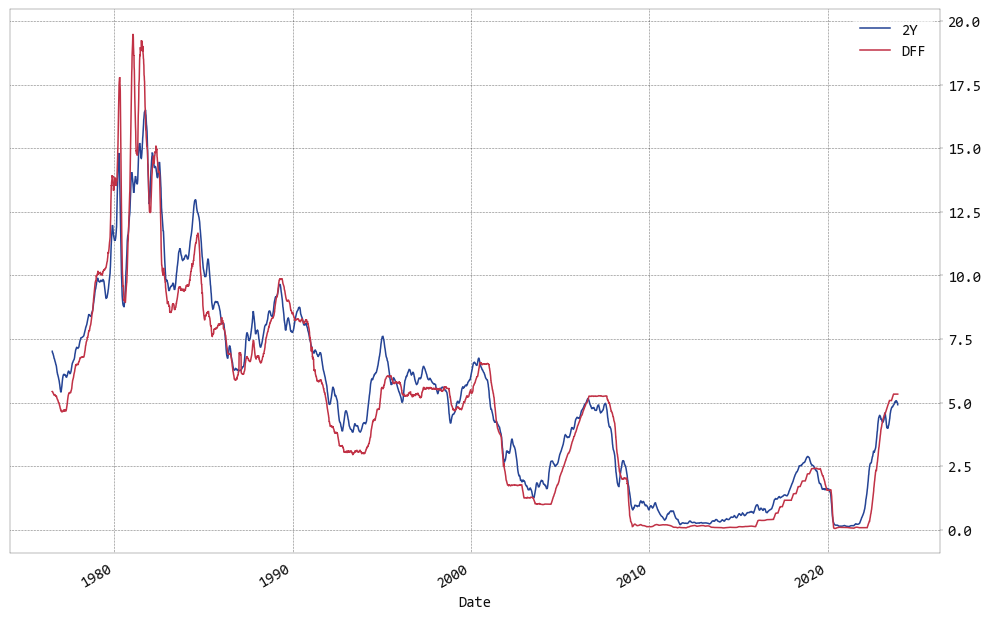

In [8]:
# check
df[['2Y', 'DFF']].dropna().fillna(method='bfill').rolling(30).mean().plot(figsize= (12,8))

In [9]:
# define momentum
# ======================================================================================================================
df_sm = make_sma(df[['Slope2Y']], spans=[50])
df_all = df.join(df_sm).dropna()

# generate signal
# ======================================================================================================================
df_all['Signal_ls'] = np.where(df_all['Slope2Y'] > df_all['Slope2Y_sm50'], 1, -1)
df_all['Signal_ln'] = np.where(df_all['Slope2Y'] > df_all['Slope2Y_sm50'], 1, 0)

<AxesSubplot: xlabel='Date'>

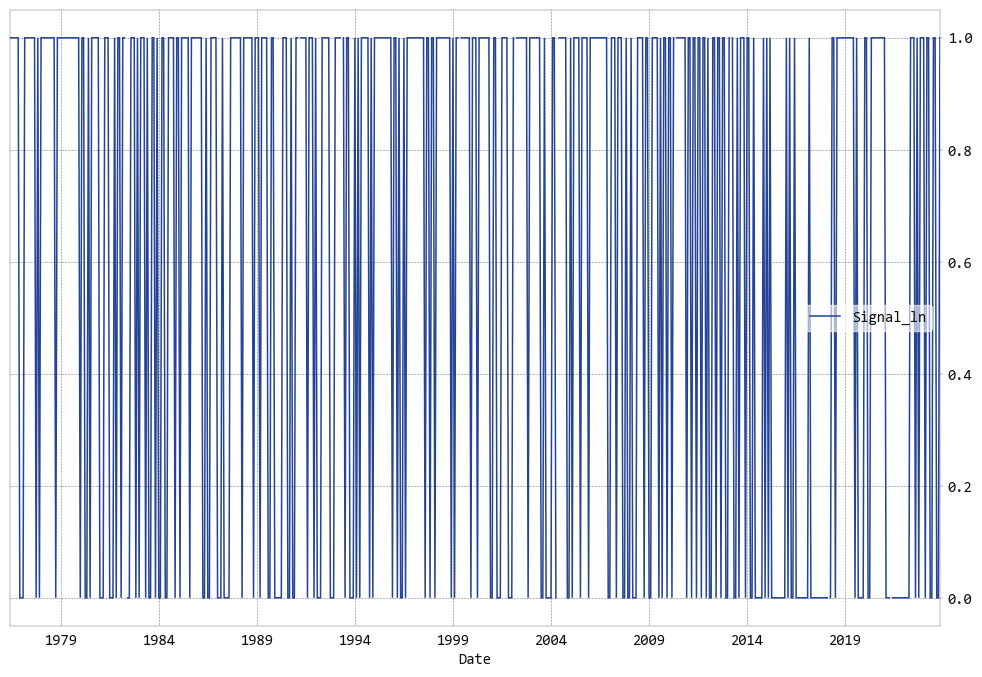

In [12]:
df_all[['Signal_ln']].dropna().asfreq('BM').plot(figsize=(12,8))

In [11]:
# Get data trading instruments: EURUSD, Stocks, Japan
# ======================================================================================================================
df_stock = get_stock_prices(yahoo_tickers=['^IXIC'], wide_format=True)
df_stock = df_stock.rename(columns={'^IXIC': 'Nasdaq'})
#df_fx = get_FX_spots(currencies=['EUR', 'JPY'], wide_format=True)
df_fx = get_FX_spots(currencies=['JPY'], wide_format=True)

df_assets = pd.concat([df_stock, df_fx], axis=1)
df_assets.index.name = df_all.index.name

# merge all
# ======================================================================================================================
df_all = df_all.join(df_assets)

get_stock_prices took 617.31ms


In [ ]:
returns_from_prices(df_assets).dropna().plot.density()
returns_from_prices(df_assets[['Nasdaq']]).cumsum().plot()
returns_from_prices(df_assets[['JPYUSD']]).cumsum().plot()

In [ ]:
performance(signal=df_all['Signal'], returns=df_all['JPYUSD'].pct_change()).dropna().cumsum().plot()

In [13]:
# performance
# ======================================================================================================================
df_perm = pd.DataFrame(index=df_all.index)
for col in ['JPYUSD']:
    # df_perm[col] = performance(signal=df_all['Signal'], returns=np.log(df_all[col]).diff()).cumsum()
    ret_temp = returns_from_prices(df_all[col])
    df_perm[col] = performance(signal=df_all['Signal_ls'], returns=ret_temp)
    #df_perm[col + '_no_TC'] = performance(signal=df_all['Signal_ls'], returns=ret_temp, bps=0)
    df_perm[col + '_ln'] = performance(signal=df_all['Signal_ln'], returns=ret_temp)
    # df_perm[col + 'str2'] = performance(signal=df_all['Signal2'], returns=np.log(df_all[col]).diff())

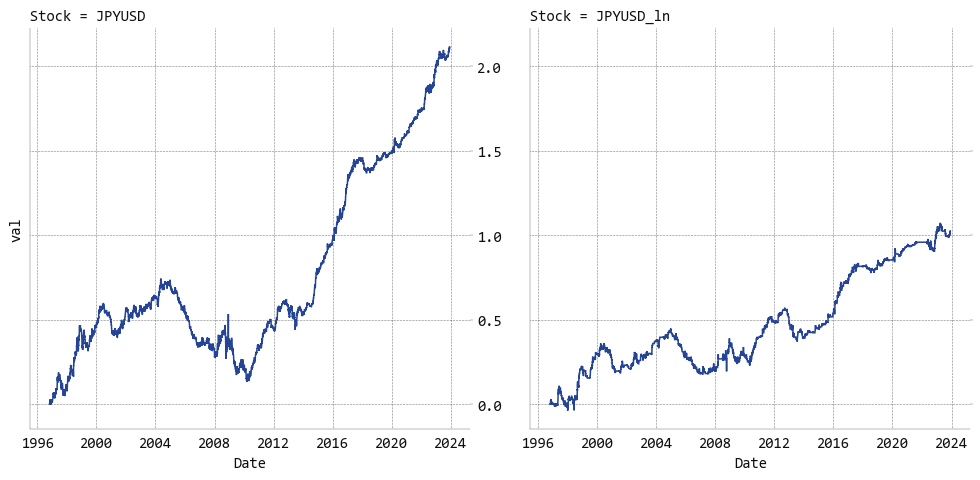

In [14]:
# from wide to long to plot
# ======================================================================================================================
dfm = df_perm.cumsum().dropna().reset_index().melt(id_vars='Date', var_name='Stock', value_name='val')
dfm['asset'] = [x.split('str')[0] for x in dfm.Stock]
g = sns.relplot(data=dfm, x='Date', y='val', col='Stock', col_wrap=3, kind='line')

In [15]:
# stats
df_perm_stats = performance_overview(df_perm, short=True).sort_values(by=['cagr'], ascending=False)
df_perm_stats

,start,end,total_return,cagr,max_drawdown,yearly_sharpe,yearly_sortino,calmar
JPYUSD,1996-10-31,2023-12-01,5.800487,0.073348,-0.498288,0.575275,1.523593,0.1472
JPYUSD_ln,1996-10-31,2023-12-01,1.535016,0.034943,-0.243313,0.41885,0.957973,0.143614


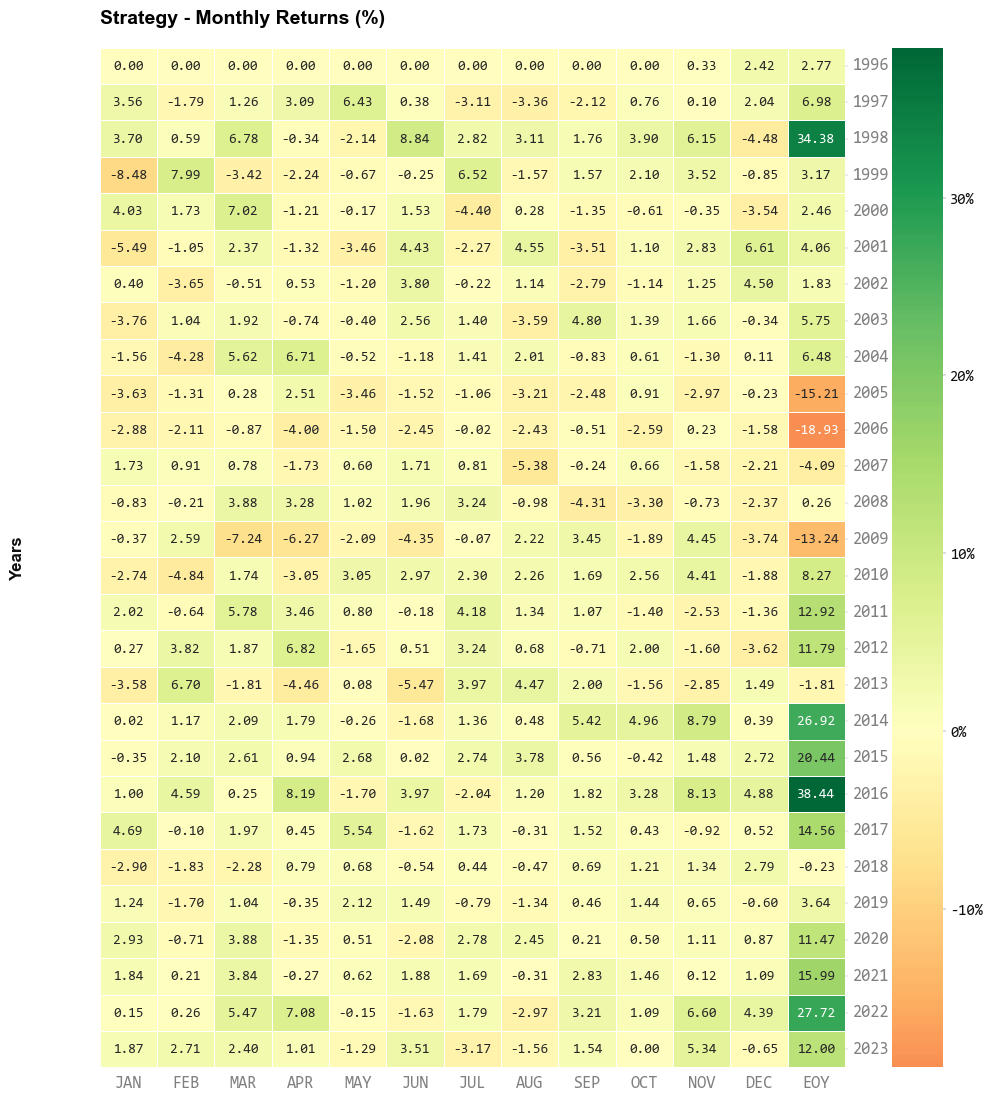

In [42]:
ret_bench = df_stock.pct_change()
df_temp = df_perm.join(ret_bench).dropna()

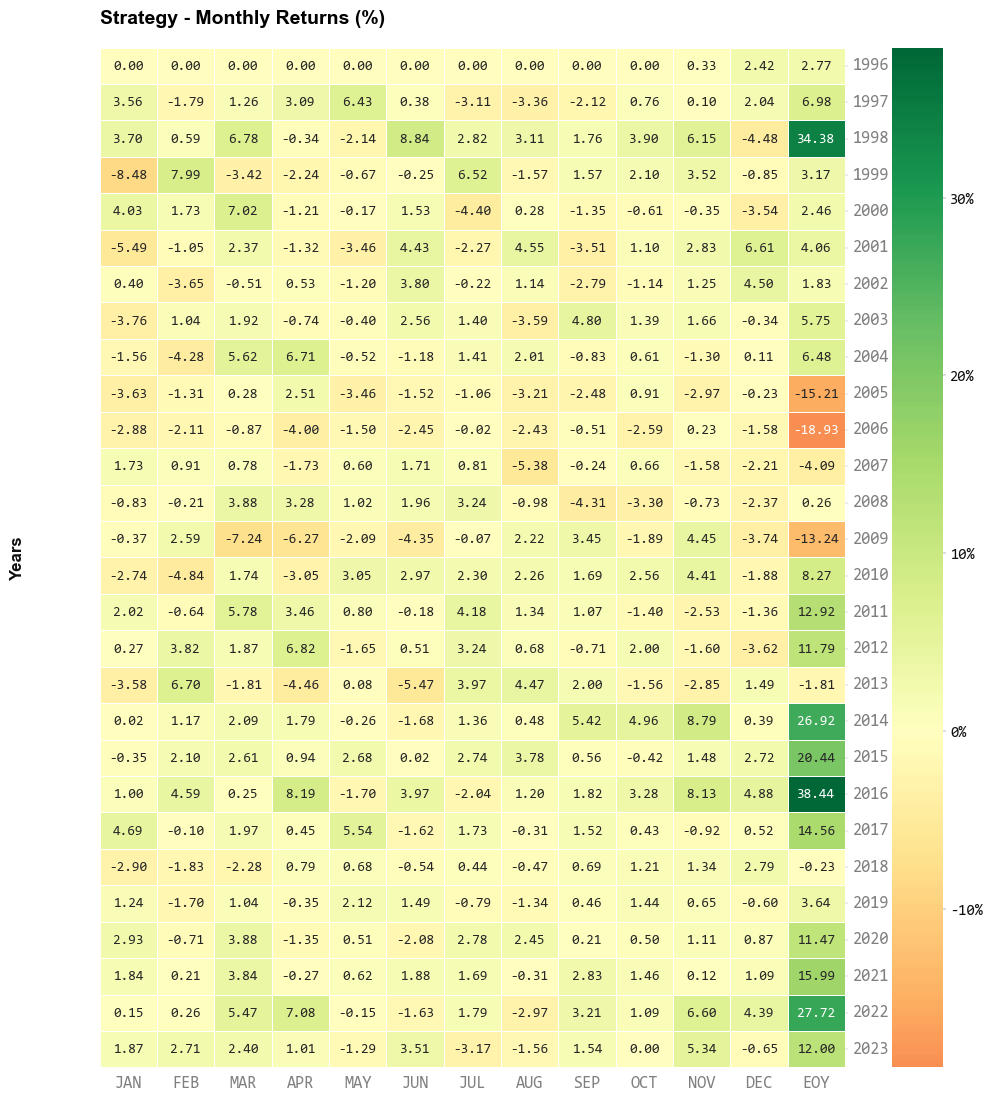

In [43]:
qs.plots.monthly_returns(df_temp['JPYUSD'], eoy=True)

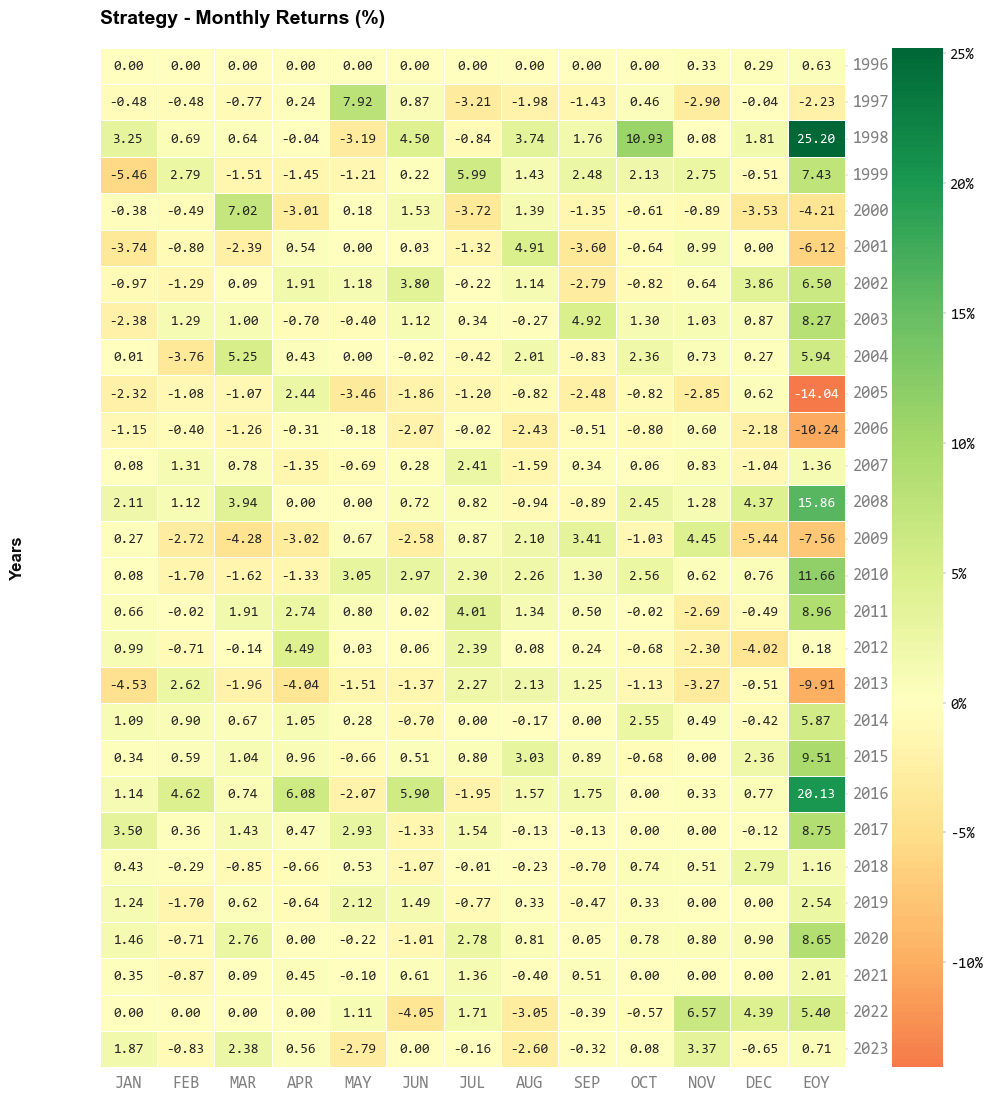

In [44]:
qs.plots.monthly_returns(df_temp['JPYUSD_ln'], eoy=True)

<AxesSubplot: >

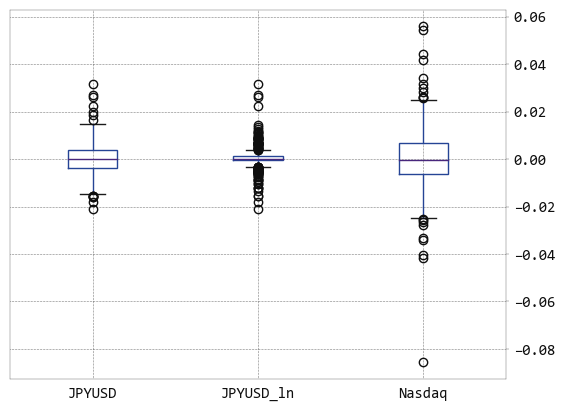

In [45]:
monthly = df_temp.resample('M').last()
monthly.boxplot()

In [46]:
get_main_stats(df_temp[df_temp.index>='2012-01-01'])

CAGR DONE:   0%|          | 0/3 [00:00<?, ?it/s]

ADJUSTED_SORTINO DONE:   0%|          | 0/3 [00:00<?, ?it/s]

SHARPE DONE:   0%|          | 0/3 [00:00<?, ?it/s]

CALMAR DONE:   0%|          | 0/3 [00:00<?, ?it/s]

MAX_DRAWDOWN DONE:   0%|          | 0/3 [00:00<?, ?it/s]

get_main_stats took 13.078sec


metric,cagr,adjusted_sortino,sharpe,calmar,max_drawdown
JPYUSD,0.146287,1.054050,0.978673,0.578578,-0.170843
JPYUSD_ln,0.043871,-0.046971,-0.044188,0.162607,-0.185029
Nasdaq,0.152303,0.500545,0.509784,0.278280,-0.369499


In [19]:
ret_boostp = bootstrappingTS(df_perm['JPYUSD'].dropna(), n_samples=10000, bootstrap_type='mbb', block_size=365*2, 
                             optimal_block = False, 
                                          seed=123)

bootstrappingTS took 2.801sec


In [20]:
stats_boostp = get_main_stats(ret_boostp)

CAGR DONE:   0%|          | 0/10000 [00:00<?, ?it/s]

ADJUSTED_SORTINO DONE:   0%|          | 0/10000 [00:00<?, ?it/s]

SHARPE DONE:   0%|          | 0/10000 [00:00<?, ?it/s]

CALMAR DONE:   0%|          | 0/10000 [00:00<?, ?it/s]

MAX_DRAWDOWN DONE:   0%|          | 0/10000 [00:00<?, ?it/s]

get_main_stats took 121.144sec


<AxesSubplot: ylabel='Density'>

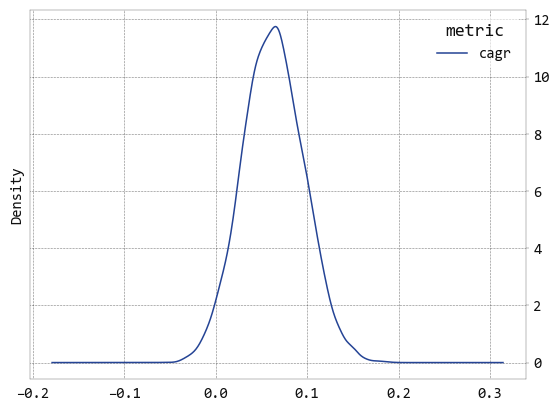

In [21]:
stats_boostp[['cagr']].plot.density()

In [22]:
df_hist = get_main_stats(df_temp)
df_hist

CAGR DONE:   0%|          | 0/2 [00:00<?, ?it/s]

ADJUSTED_SORTINO DONE:   0%|          | 0/2 [00:00<?, ?it/s]

SHARPE DONE:   0%|          | 0/2 [00:00<?, ?it/s]

CALMAR DONE:   0%|          | 0/2 [00:00<?, ?it/s]

MAX_DRAWDOWN DONE:   0%|          | 0/2 [00:00<?, ?it/s]

get_main_stats took 12.669sec


metric,cagr,adjusted_sortino,sharpe,calmar,max_drawdown
JPYUSD,0.072404,0.213836,0.212399,0.099154,-0.498667
Nasdaq,0.086746,0.250413,0.252386,0.075745,-0.780454


In [34]:
boost_mean = ret_boostp.resample('Y').last().mean().mean()

In [35]:
hist_ret = returns_from_prices(df_assets['JPYUSD']).resample('Y').last().dropna()

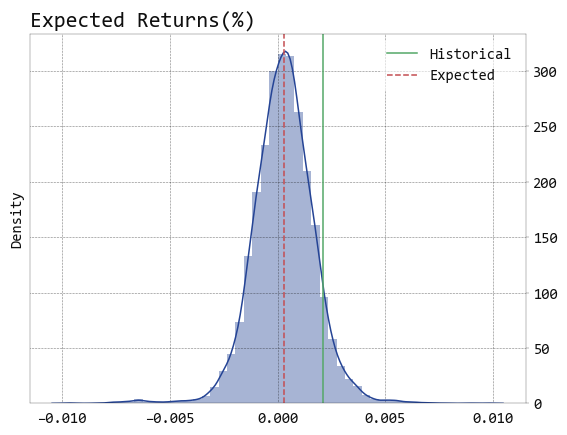

In [36]:
sns.distplot(ret_boostp.resample('Y').last().mean(), hist=True)
plt.axvline(x=hist_ret.mean(), color='g', linestyle='-', label='Historical')
plt.axvline(x=boost_mean, color='r', linestyle='--', label='Expected')
plt.title('Expected Returns(%)')
plt.legend()

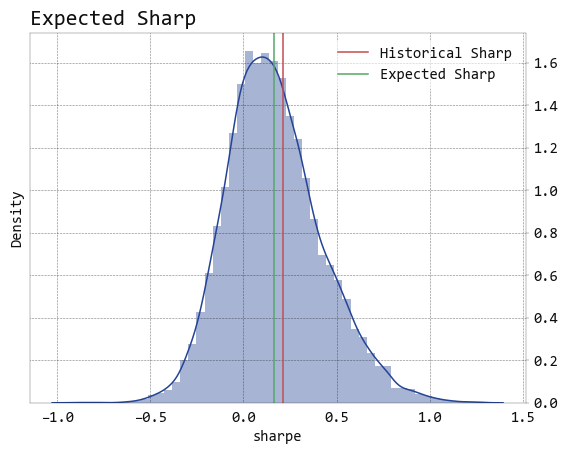

In [37]:
metric = 'sharpe'
hist_sharp = df_hist.loc['JPYUSD']['sharpe']
boost_sharp = stats_boostp[['sharpe']].mean()[0]
sns.distplot(stats_boostp[metric], hist=True)
plt.axvline(x=hist_sharp, color='r', linestyle='-', label = 'Historical Sharp')
plt.axvline(x=boost_sharp, color='g', linestyle='-', label = 'Expected Sharp')
plt.title('Expected Sharp')
plt.legend()

<AxesSubplot: xlabel='JPYUSD', ylabel='Density'>

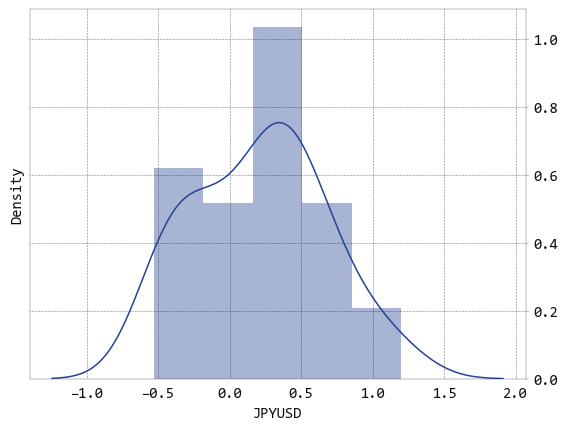

In [38]:
hist_ret.index = pd.to_datetime(hist_ret.index).normalize()
sns.distplot(hist_ret*100, hist=True)

                           Benchmark    Strategy
-------------------------  -----------  ----------
Start Period               1996-11-01   1996-11-01
End Period                 2023-12-01   2023-12-01
Risk-Free Rate             5.0%         5.0%
Time in Market             100.0%       100.0%

Cumulative Return          841.14%      564.89%
CAGR﹪                     5.88%        4.95%

Sharpe                     0.26         0.24
Prob. Sharpe Ratio         4.18%        23.62%
Smart Sharpe               0.23         0.21
Sortino                    0.37         0.35
Smart Sortino              0.32         0.3
Sortino/√2                 0.26         0.24
Smart Sortino/√2           0.23         0.21
Omega                      1.05         1.05

Max Drawdown               -78.05%      -49.87%
Longest DD Days            6179         4005
Volatility (ann.)          25.0%        11.96%
R^2                        0.0          0.0
Information Ratio          -0.01        -0.01
Calmar             

None

,Start,Valley,End,Days,Max Drawdown,99% Max Drawdown
1,2004-05-14,2010-05-04,2015-05-01,4005,-49.866741,-48.696698
2,2000-06-23,2001-06-04,2003-11-26,1252,-18.780746,-17.927388
3,1998-11-16,1999-06-11,2000-01-05,416,-14.922106,-13.824718
4,1997-06-12,1997-11-10,1998-03-27,289,-13.333828,-13.035688
5,2017-11-07,2018-04-18,2019-01-02,422,-9.213991,-8.934896


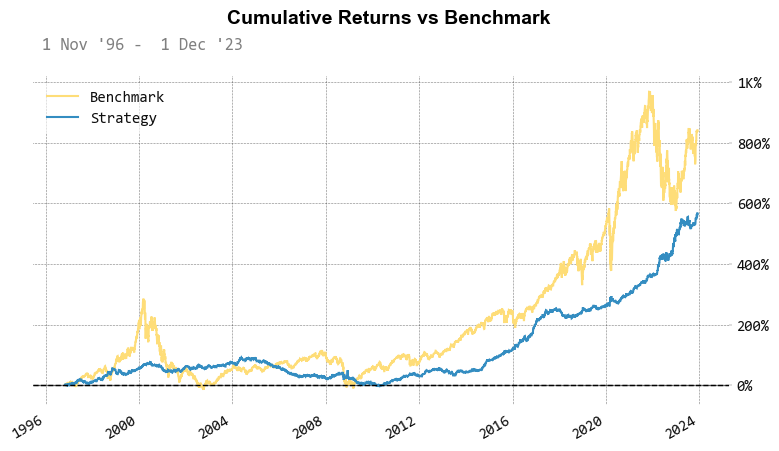

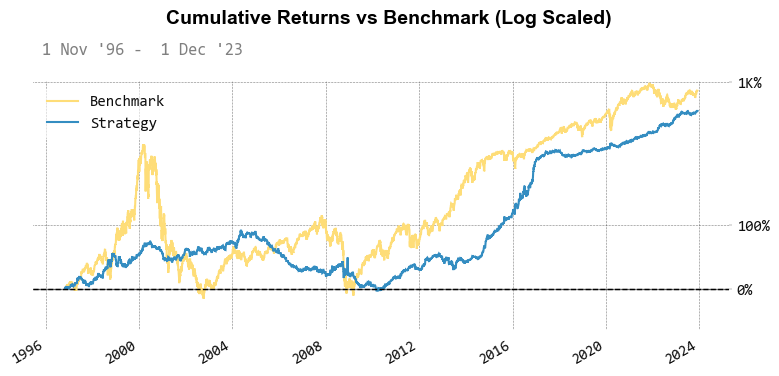

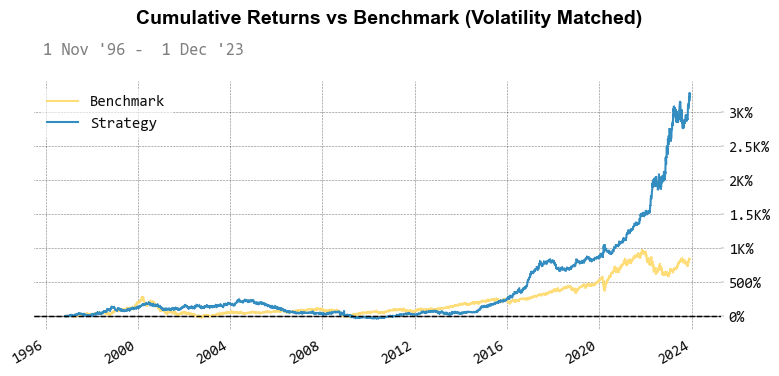

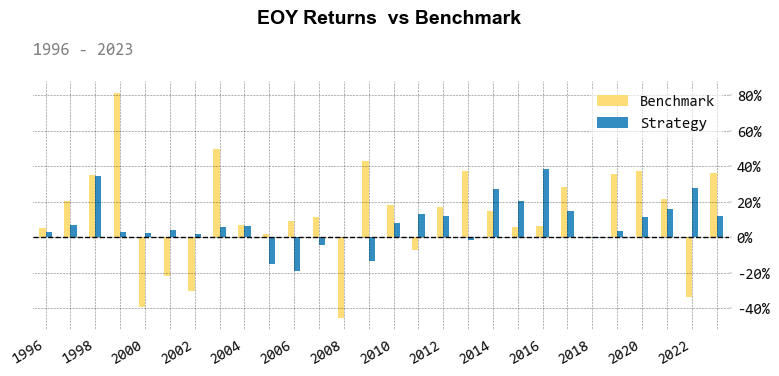

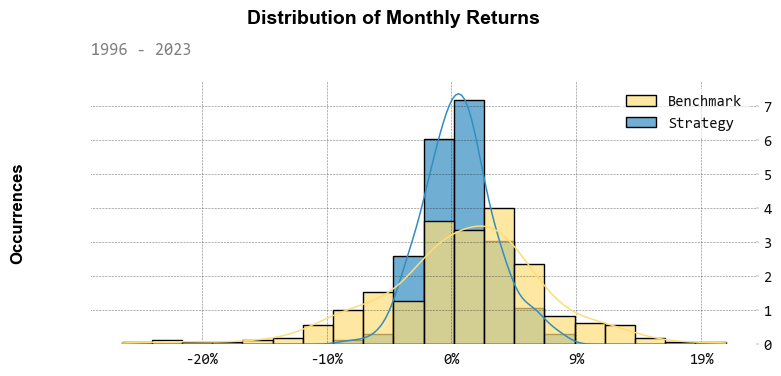

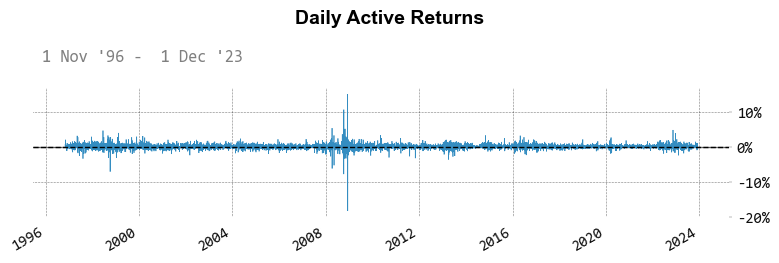

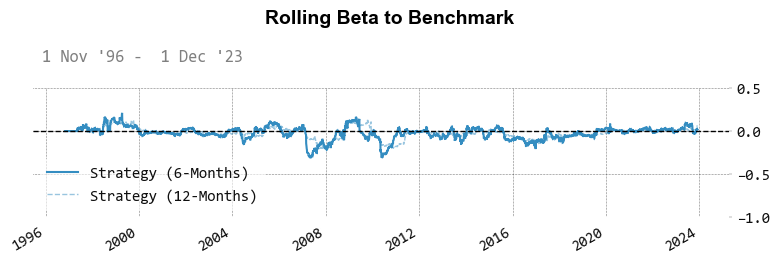

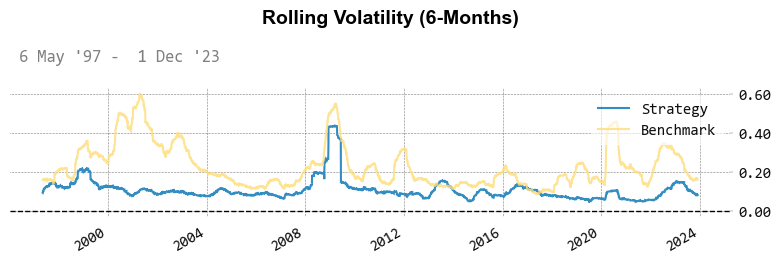

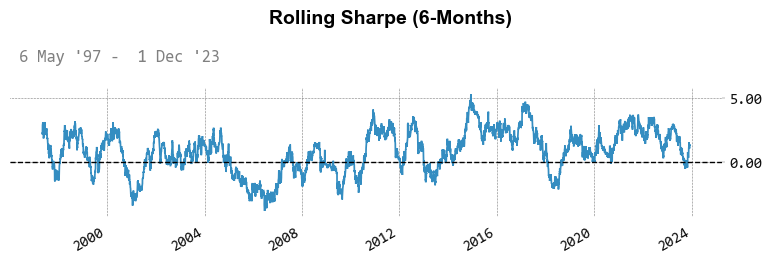

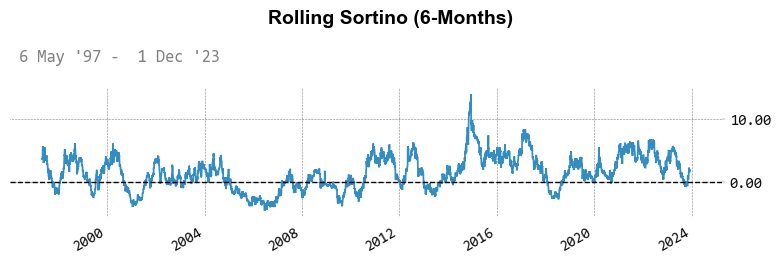

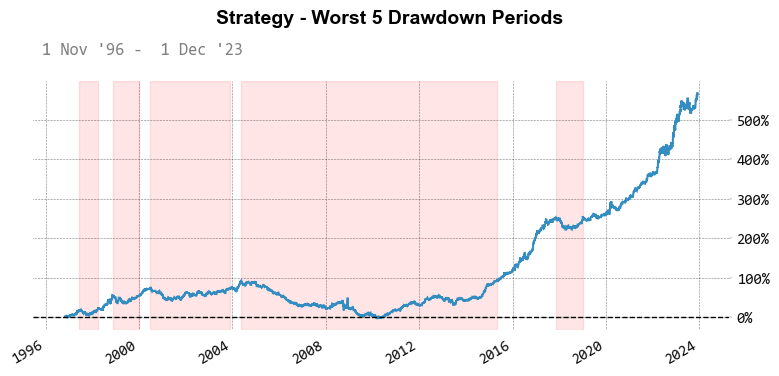

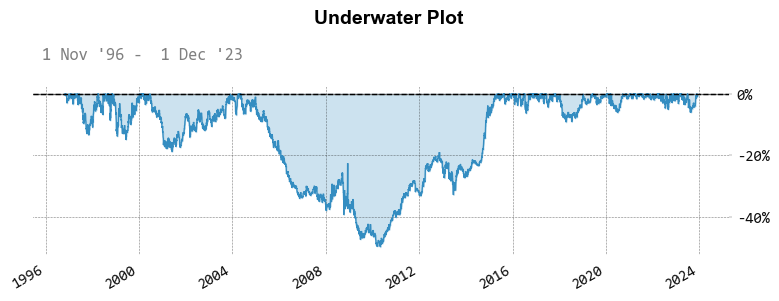

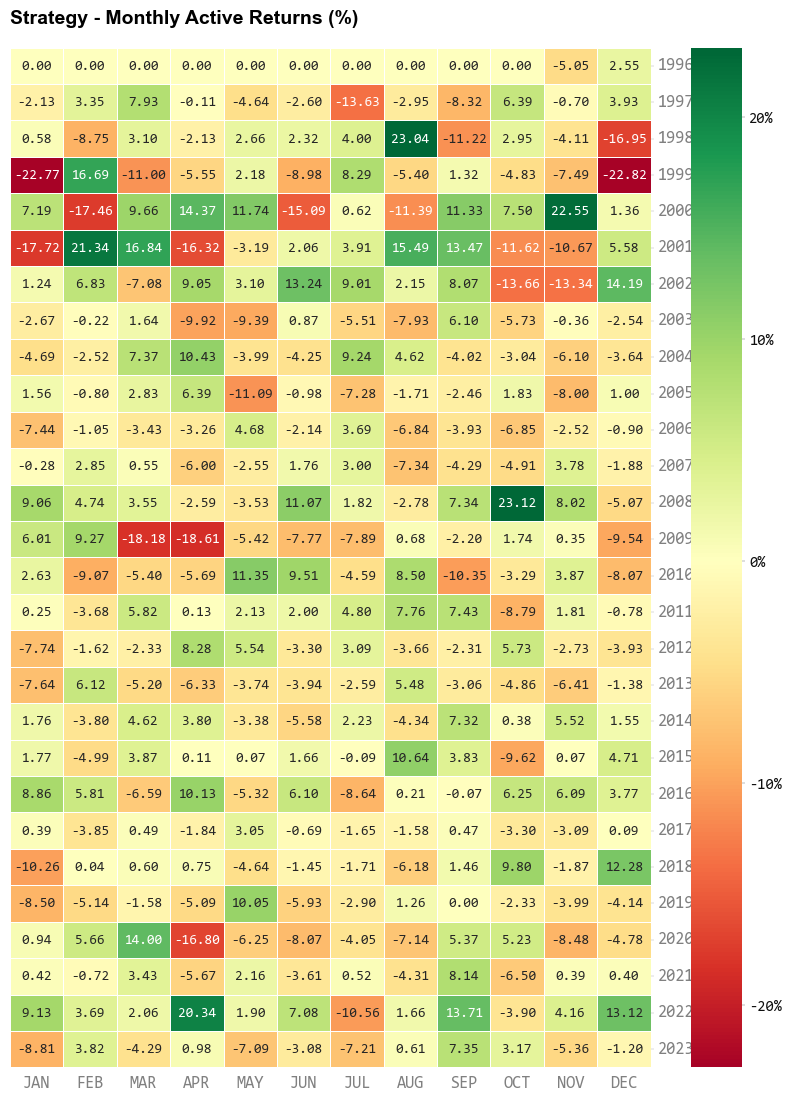

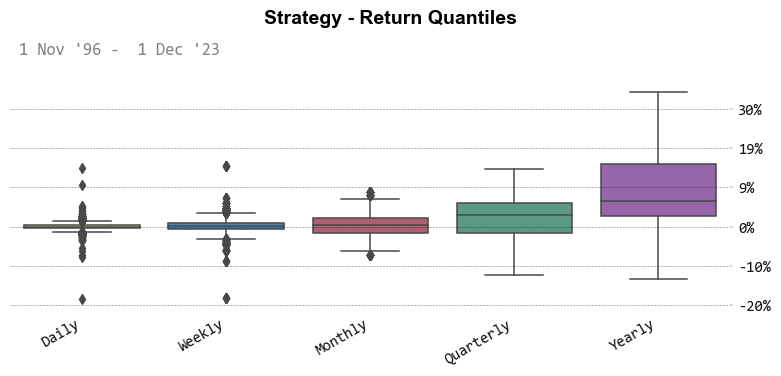

In [39]:
 qs.reports.full(df_temp['JPYUSD'], benchmark=df_temp['Nasdaq'], rf=0.05)

                           Benchmark    Strategy
-------------------------  -----------  ----------
Start Period               1996-11-01   1996-11-01
End Period                 2023-12-01   2023-12-01
Risk-Free Rate             5.0%         5.0%
Time in Market             100.0%       59.0%

Cumulative Return          841.14%      147.08%
CAGR﹪                     5.88%        2.33%

Sharpe                     0.26         -0.14
Prob. Sharpe Ratio         4.18%        3.54%
Smart Sharpe               0.24         -0.13
Sortino                    0.37         -0.21
Smart Sortino              0.34         -0.2
Sortino/√2                 0.26         -0.15
Smart Sortino/√2           0.24         -0.14
Omega                      0.97         0.97

Max Drawdown               -78.05%      -24.33%
Longest DD Days            6179         2388
Volatility (ann.)          25.0%        8.24%
R^2                        0.01         0.01
Information Ratio          -0.02        -0.02
Calmar         

None

,Start,Valley,End,Days,Max Drawdown,99% Max Drawdown
1,2004-12-28,2007-02-22,2011-07-12,2388,-24.331258,-23.589100
2,2012-09-17,2013-07-19,2016-02-08,1240,-18.502911,-17.212506
3,2000-06-23,2002-04-15,2004-08-16,1516,-17.463909,-16.937019
4,1997-06-12,1998-01-06,1998-09-03,449,-13.892188,-12.661495
5,2023-03-28,2023-10-27,2023-12-01,249,-7.606856,-7.423379


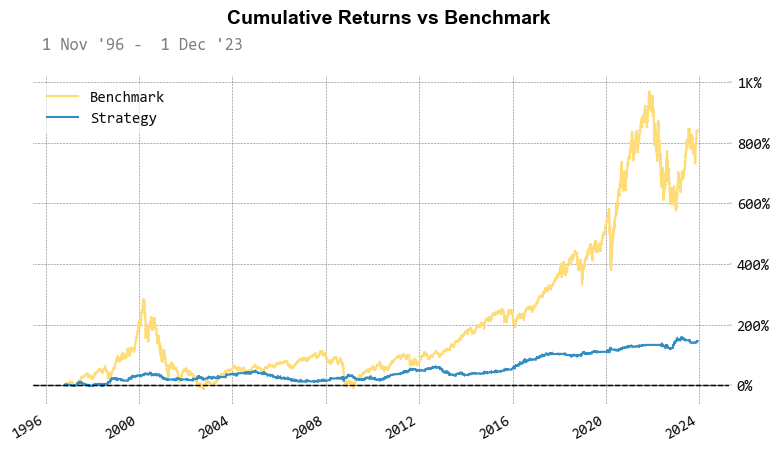

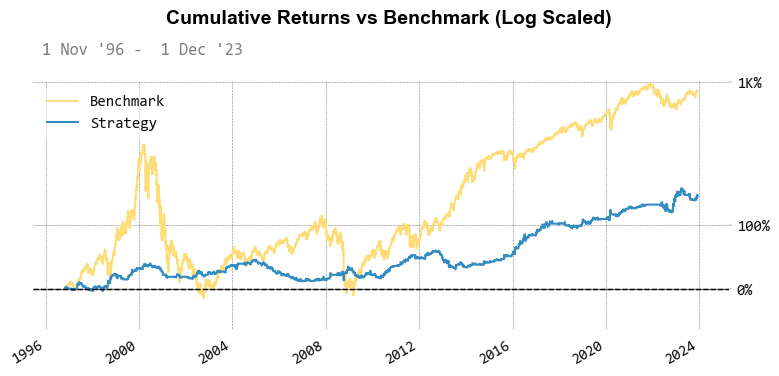

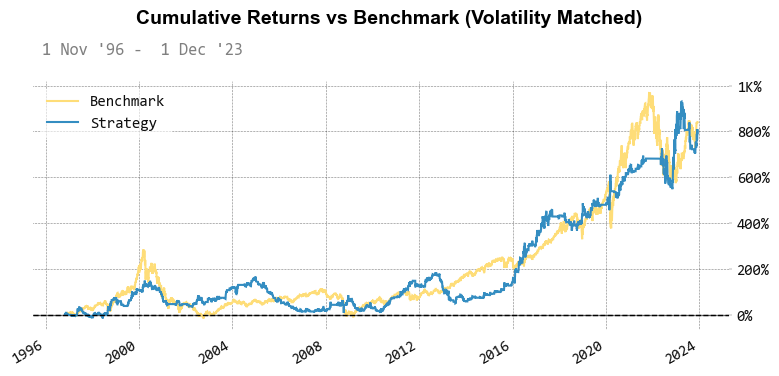

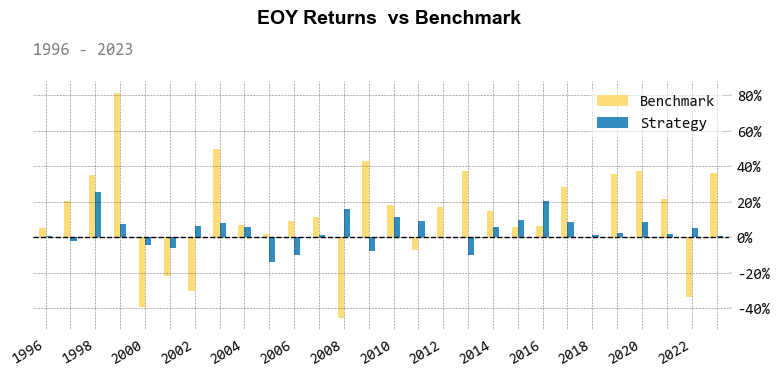

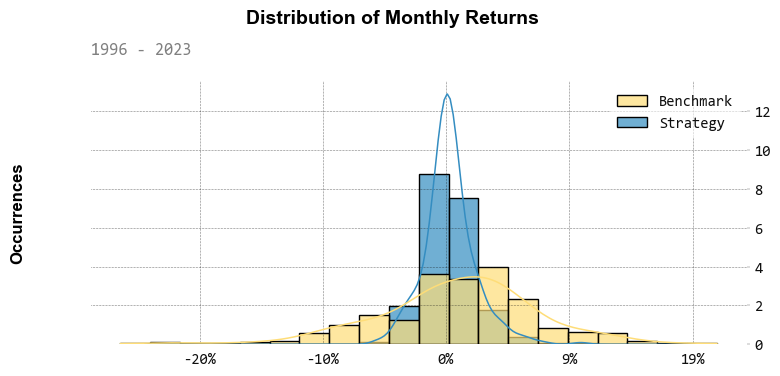

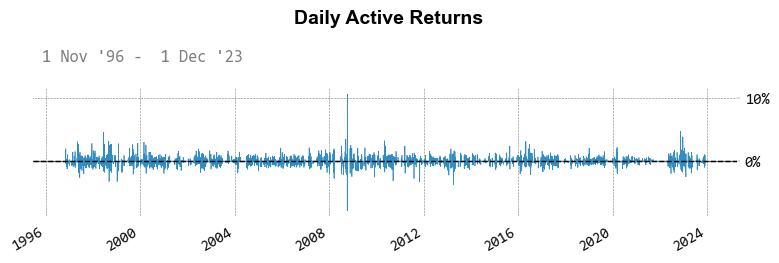

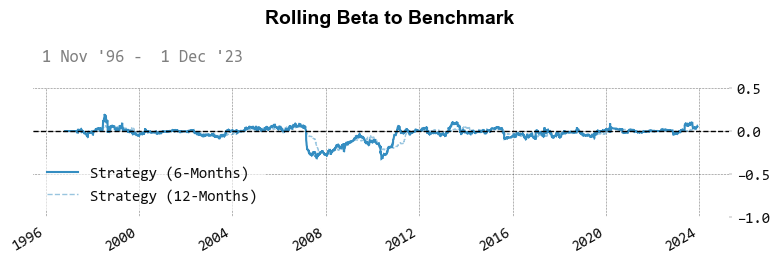

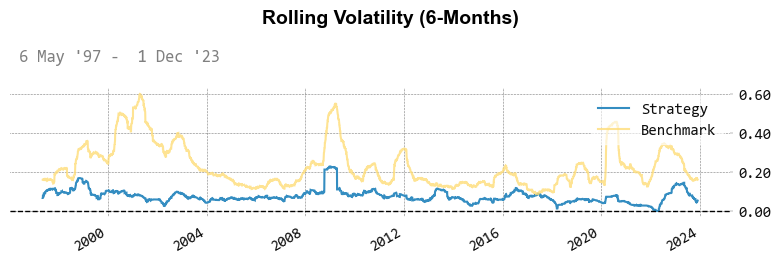

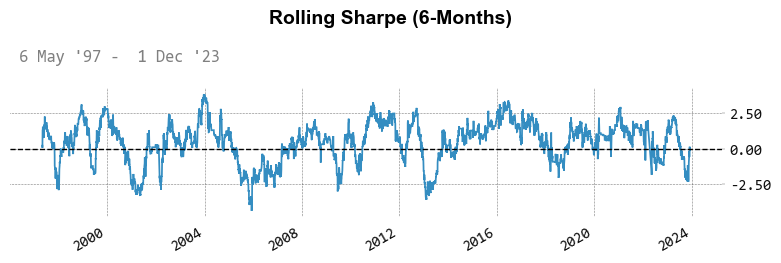

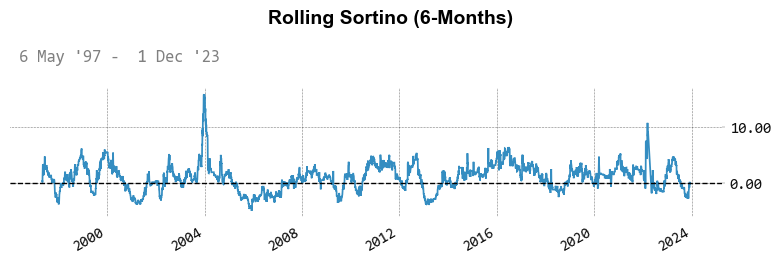

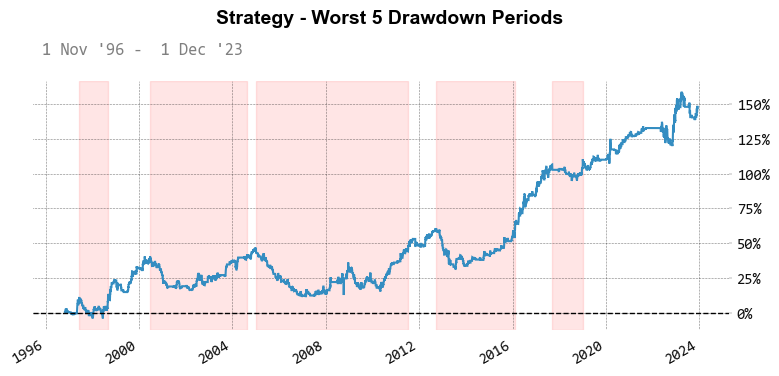

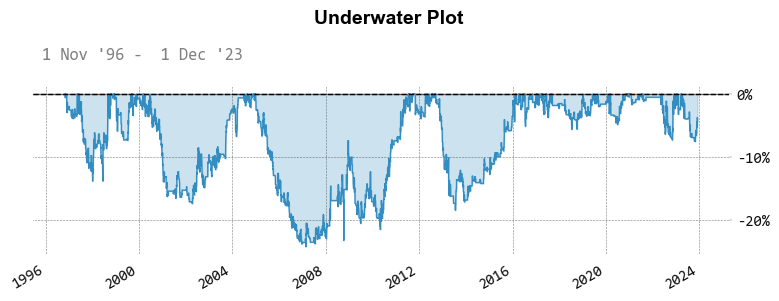

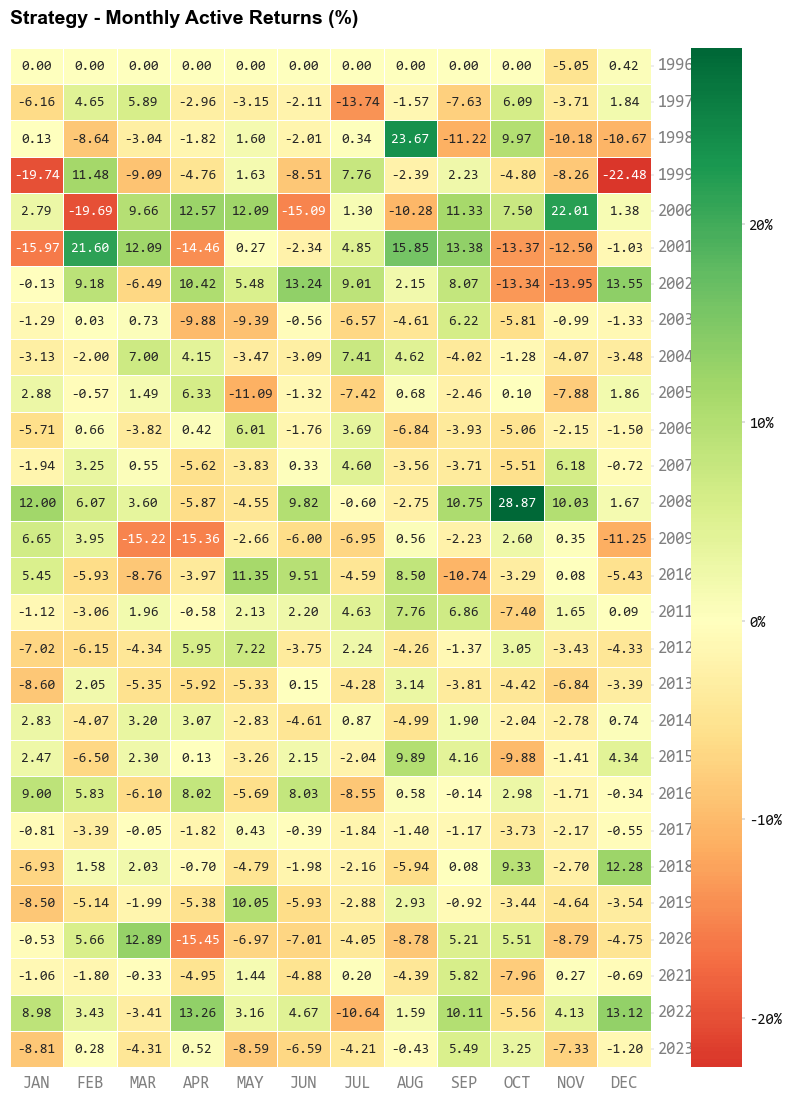

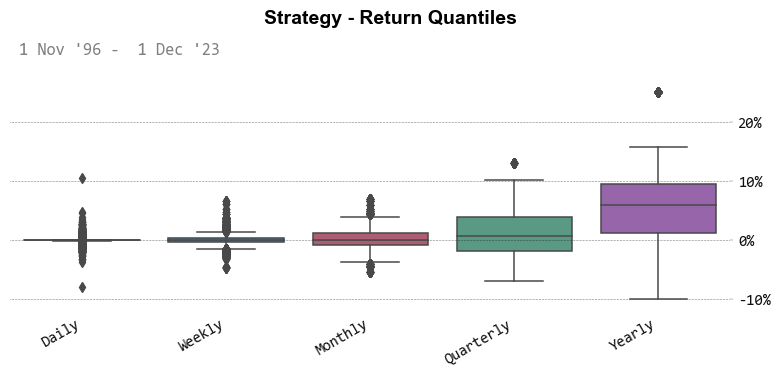

In [47]:
qs.reports.full(df_temp['JPYUSD_ln'], benchmark=df_temp['Nasdaq'], rf=0.05)

In [48]:
dist = prep_dist(ret_boostp)

<AxesSubplot: xlabel='Date'>

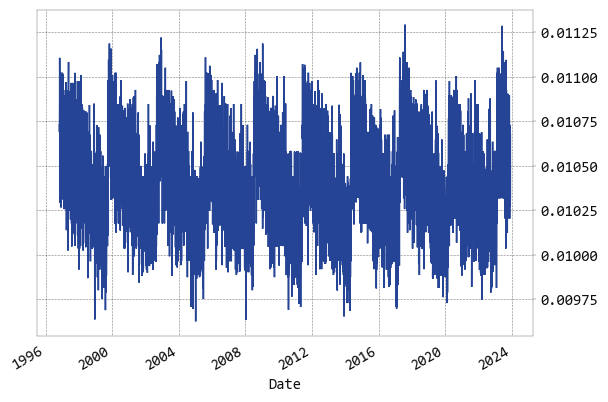

In [49]:
dist['0.95'].plot()

In [50]:
dist_cum = ep.cum_returns(dist, starting_value=1)

In [51]:
pd.set_option('display.float_format', str)
round(dist_cum['0.95'],2)

Date
1996-10-31                     1.01
1996-11-01                     1.02
1996-11-04                     1.03
1996-11-05                     1.04
1996-11-06                     1.06
                      ...          
2023-11-27    2.564198976768595e+30
2023-11-28    2.591711220615389e+30
2023-11-29   2.6183312657537136e+30
2023-11-30    2.646299824985743e+30
2023-12-01   2.6736033628500996e+30
Name: 0.95, Length: 6776, dtype: float64

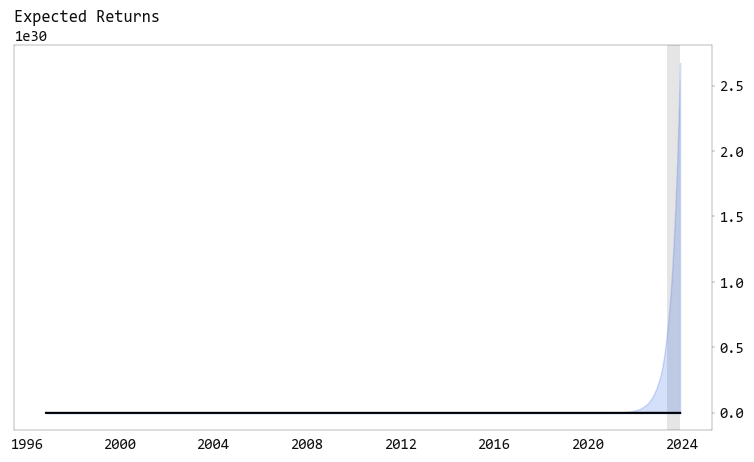

In [53]:
plot_fan_chart(df_temp[['JPYUSD']],dist_cum, out_of_sample_date='2023-05-12',
                   starting_value=1,
                   chart_title='Expected Returns')

In [ ]:
from fanchart import load_boe_history, load_boe_parameters
from fanchart import fan

history = load_boe_history()
parameters = load_boe_parameters()
    


In [ ]:
history

In [ ]:
probs = [0.05, 0.20, 0.35, 0.65,0.80,  0.95]
parameters

In [ ]:
fan(pars=parameters, probs=probs, historic=history[history.Date >= '2018'])

In [ ]:
param = pd.concat([ret_boostp.median(axis=1), ret_boostp.std(axis=1), ret_boostp.skew(axis=1)], axis=1)
param.columns = ['Mode','Uncertainty', 'Skewness']
param = param.reset_index()
param

In [ ]:
hist = df_temp[['JPYUSD']].reset_index()
hist = hist.rename(columns={'JPYUSD':'Inflation'})
fan(pars=param, probs=probs, historic=hist[hist.Date >= '2020'])